# 第7章: 極限定理と漸近理論

## 学習目標
- 大数の法則を理解する
- 中心極限定理を理解し応用できる
- デルタ法による分散の近似を理解する

## 📋 学習メタ情報

### 学習目標
（既存の学習目標を活用）

### 推定学習時間
**120〜150分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

中心極限定理は統計学の最も重要な定理の一つです。サンプルサイズが大きければ、元の分布に関わらず標本平均が正規分布に従うことを保証し、推定・検定の理論的基礎となります。

### 実世界での応用

**世論調査の信頼区間**: 中心極限定理により、標本平均の分布が正規分布に近似できるため、信頼区間を計算可能

**品質管理の管理図**: サンプル平均の管理図は、中心極限定理に基づいて異常を検出

**モンテカルロシミュレーション**: 大数の法則により、シミュレーション回数を増やせば真の値に収束

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 7.1 大数の法則

### 弱法則（チェビシェフの不等式による）
$$P(|\bar{X}_n - \mu| > \epsilon) \to 0 \text{ as } n \to \infty$$

### 強法則
$$P\left(\lim_{n \to \infty} \bar{X}_n = \mu\right) = 1$$

標本平均は真の期待値に収束する。

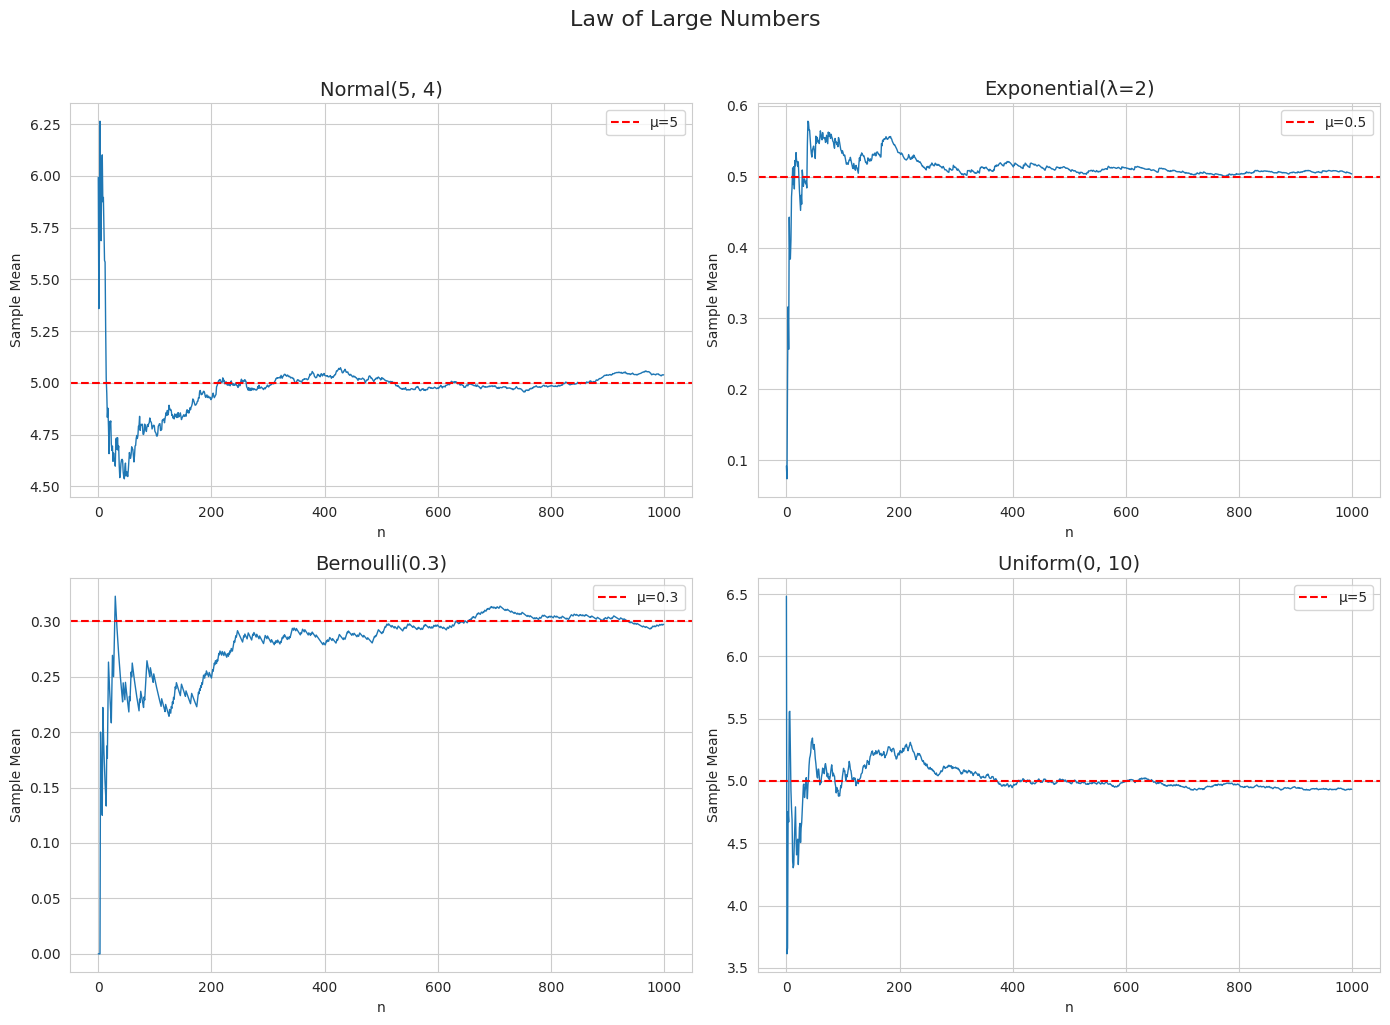

In [2]:
# 大数の法則の可視化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

n_max = 1000

distributions = [
    ('Normal(5, 4)', lambda n: np.random.normal(5, 2, n), 5),
    ('Exponential(λ=2)', lambda n: np.random.exponential(0.5, n), 0.5),
    ('Bernoulli(0.3)', lambda n: np.random.binomial(1, 0.3, n), 0.3),
    ('Uniform(0, 10)', lambda n: np.random.uniform(0, 10, n), 5)
]

for idx, (name, sampler, true_mean) in enumerate(distributions):
    row, col = idx // 2, idx % 2
    
    samples = sampler(n_max)
    cumulative_means = np.cumsum(samples) / np.arange(1, n_max + 1)
    
    axes[row, col].plot(cumulative_means, linewidth=1)
    axes[row, col].axhline(true_mean, color='r', linestyle='--', label=f'μ={true_mean}')
    axes[row, col].set_title(f'{name}', fontsize=14)
    axes[row, col].set_xlabel('n')
    axes[row, col].set_ylabel('Sample Mean')
    axes[row, col].legend()

plt.suptitle('Law of Large Numbers', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 7.2 中心極限定理 (CLT)

### 定理
$X_1, ..., X_n$ が iid で $E[X_i] = \mu$, $Var(X_i) = \sigma^2 < \infty$ のとき:

$$\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} N(0, 1)$$

または

$$\sqrt{n}(\bar{X}_n - \mu) \xrightarrow{d} N(0, \sigma^2)$$

元の分布に関係なく、標本平均は正規分布に近づく。

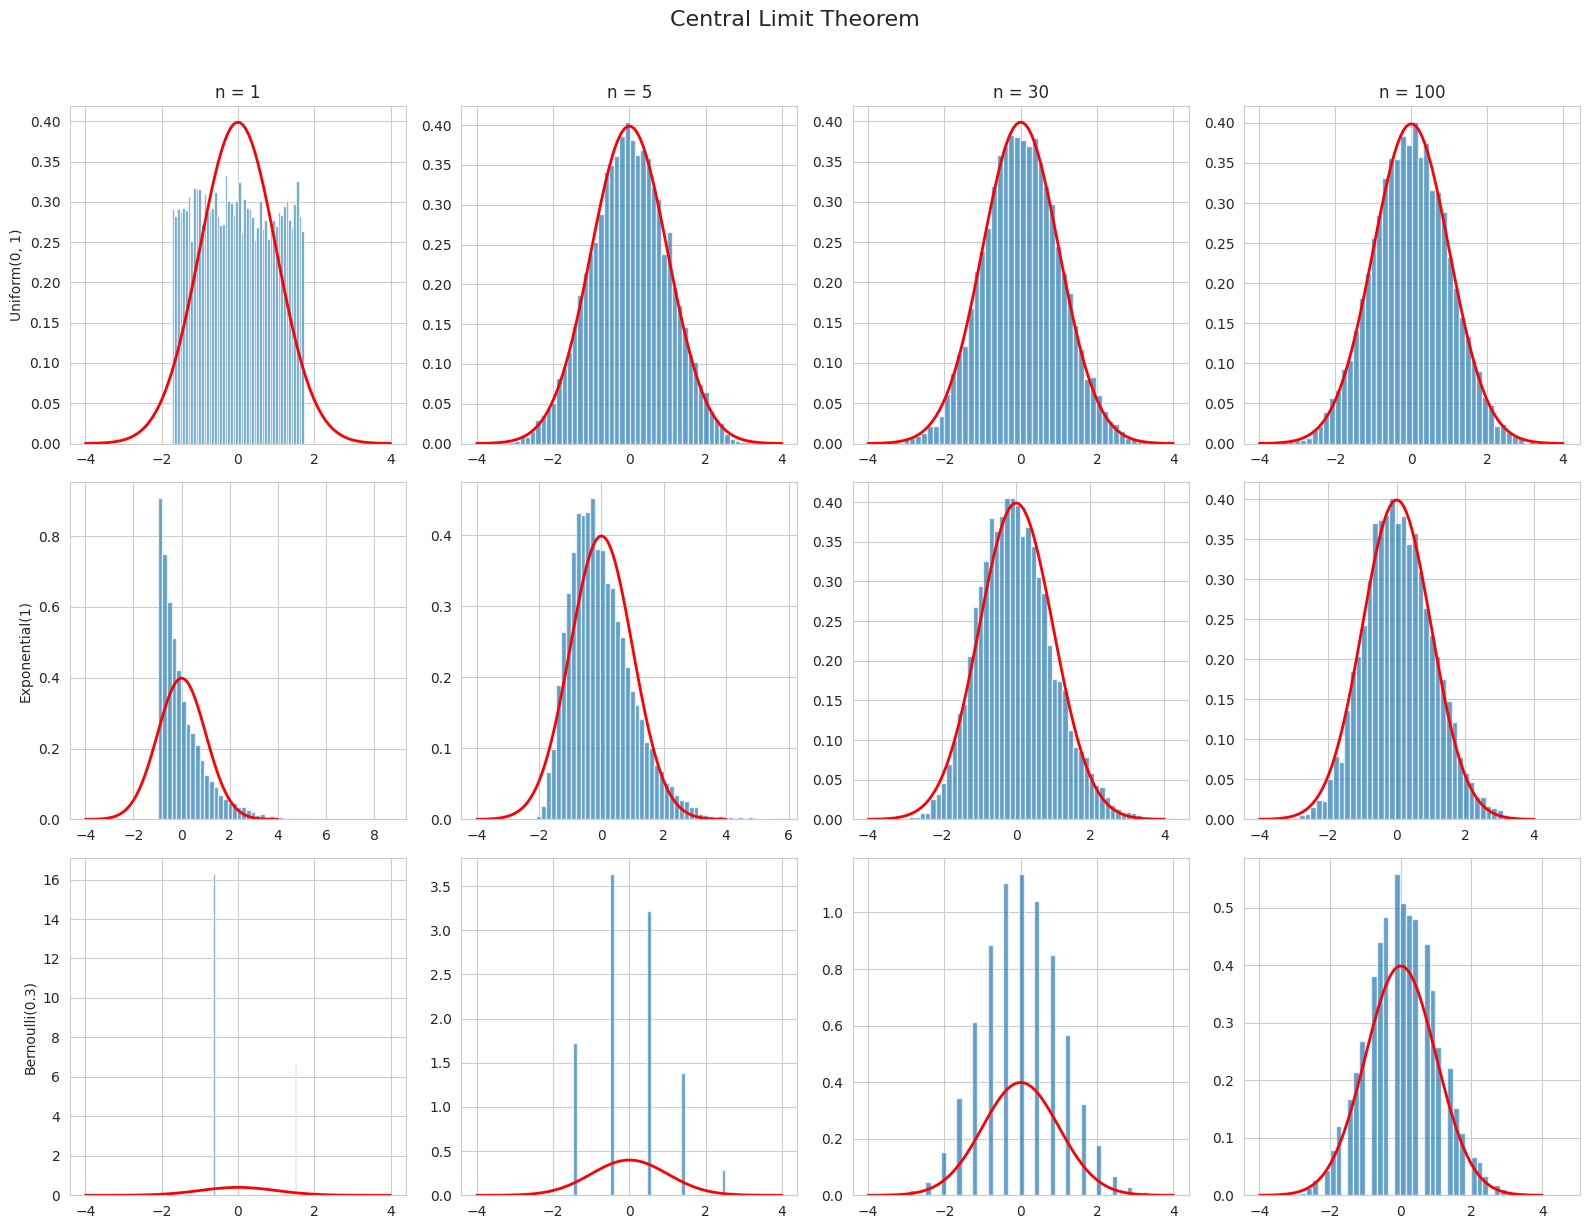

In [3]:
# 中心極限定理の可視化
n_simulations = 10000

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# 異なる元分布
distributions = [
    ('Uniform(0, 1)', lambda n: np.random.uniform(0, 1, n)),
    ('Exponential(1)', lambda n: np.random.exponential(1, n)),
    ('Bernoulli(0.3)', lambda n: np.random.binomial(1, 0.3, n))
]

sample_sizes = [1, 5, 30, 100]

for row, (name, sampler) in enumerate(distributions):
    for col, n in enumerate(sample_sizes):
        # 標本平均を計算
        sample_means = np.mean(sampler((n_simulations, n)), axis=1)
        
        # 標準化
        samples = sampler(100000)
        mu = np.mean(samples)
        sigma = np.std(samples)
        standardized = (sample_means - mu) / (sigma / np.sqrt(n))
        
        axes[row, col].hist(standardized, bins=50, density=True, alpha=0.7)
        x = np.linspace(-4, 4, 100)
        axes[row, col].plot(x, stats.norm.pdf(x), 'r-', linewidth=2)
        
        if row == 0:
            axes[row, col].set_title(f'n = {n}', fontsize=12)
        if col == 0:
            axes[row, col].set_ylabel(name, fontsize=10)

plt.suptitle('Central Limit Theorem', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

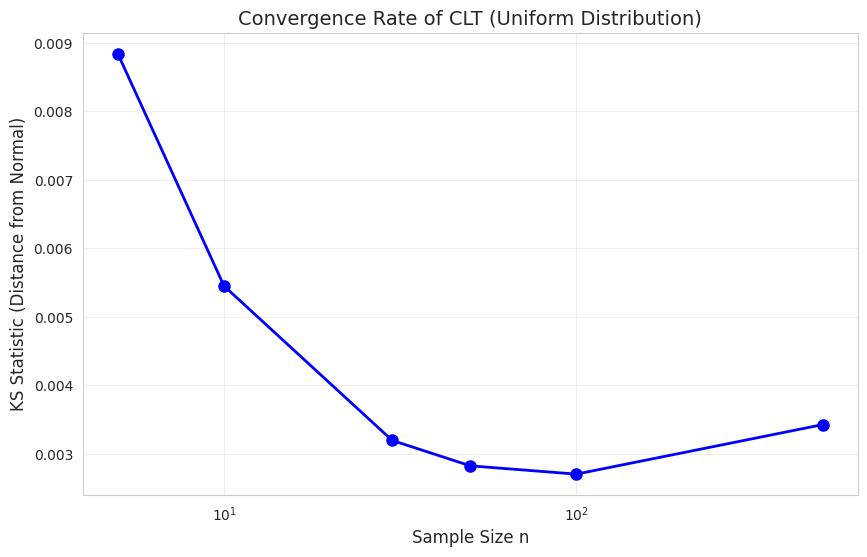

In [4]:
# CLTの収束速度
n_simulations = 50000

sample_sizes = [5, 10, 30, 50, 100, 500]

# 一様分布からの標本
fig, ax = plt.subplots(figsize=(10, 6))

# Kolmogorov-Smirnov統計量で正規性を測定
ks_stats = []

for n in sample_sizes:
    sample_means = np.mean(np.random.uniform(0, 1, (n_simulations, n)), axis=1)
    mu = 0.5
    sigma = 1 / np.sqrt(12)
    standardized = (sample_means - mu) / (sigma / np.sqrt(n))
    
    ks_stat, _ = stats.kstest(standardized, 'norm')
    ks_stats.append(ks_stat)

ax.plot(sample_sizes, ks_stats, 'bo-', markersize=8, linewidth=2)
ax.set_xlabel('Sample Size n', fontsize=12)
ax.set_ylabel('KS Statistic (Distance from Normal)', fontsize=12)
ax.set_title('Convergence Rate of CLT (Uniform Distribution)', fontsize=14)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
plt.show()

## 7.3 デルタ法

### 定理
$\sqrt{n}(X_n - \theta) \xrightarrow{d} N(0, \sigma^2)$ のとき、$g(\theta)$ が微分可能で $g'(\theta) \neq 0$ なら:

$$\sqrt{n}(g(X_n) - g(\theta)) \xrightarrow{d} N(0, [g'(\theta)]^2 \sigma^2)$$

### 応用例
- $g(p) = \log(p/(1-p))$ (ロジット変換)
- $g(\sigma^2) = \log(\sigma^2)$

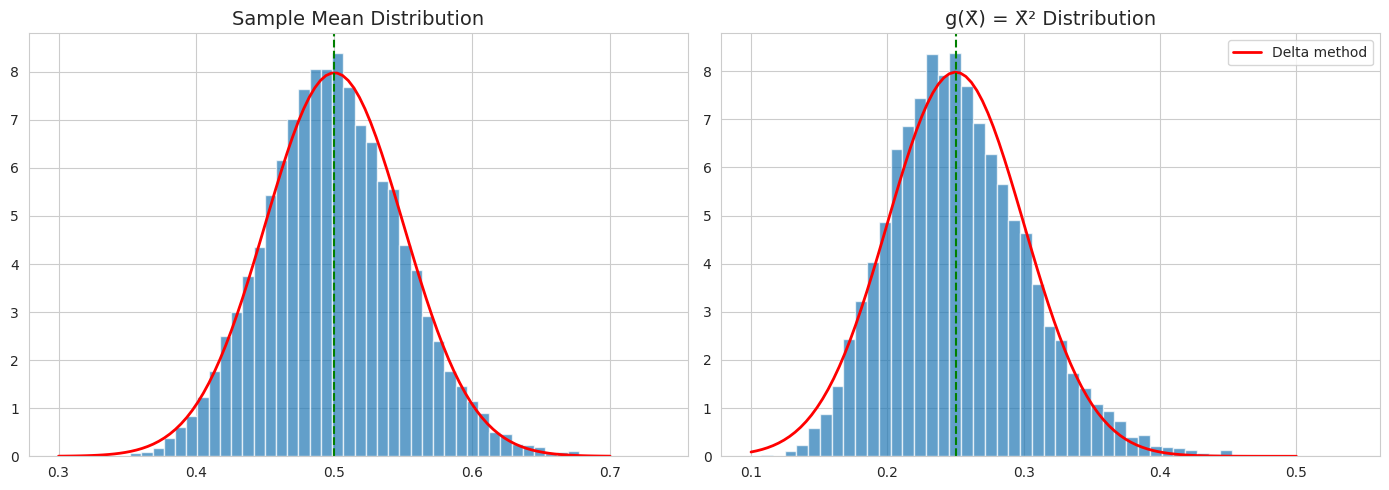

g(μ) = μ² = 0.25
デルタ法による漸近分散: 0.002500
シミュレーション分散: 0.002564


In [5]:
# デルタ法の例：標本平均の関数
n_simulations = 10000
n = 100  # 標本サイズ

# 指数分布からの標本
lam = 2
true_mean = 1 / lam  # = 0.5
true_var = 1 / lam**2  # = 0.25

# g(μ) = μ² を考える
# g'(μ) = 2μ

sample_means = np.mean(np.random.exponential(true_mean, (n_simulations, n)), axis=1)
g_sample = sample_means**2

# 真の値と漸近分散
g_true = true_mean**2  # = 0.25
g_prime = 2 * true_mean  # = 1
asymptotic_var = g_prime**2 * true_var / n

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 標本平均の分布
axes[0].hist(sample_means, bins=50, density=True, alpha=0.7)
x = np.linspace(0.3, 0.7, 100)
axes[0].plot(x, stats.norm.pdf(x, true_mean, np.sqrt(true_var/n)), 'r-', linewidth=2)
axes[0].axvline(true_mean, color='g', linestyle='--')
axes[0].set_title('Sample Mean Distribution', fontsize=14)

# g(X̄)の分布
axes[1].hist(g_sample, bins=50, density=True, alpha=0.7)
x = np.linspace(0.1, 0.5, 100)
axes[1].plot(x, stats.norm.pdf(x, g_true, np.sqrt(asymptotic_var)), 'r-', linewidth=2,
             label='Delta method')
axes[1].axvline(g_true, color='g', linestyle='--')
axes[1].set_title('g(X̄) = X̄² Distribution', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"g(μ) = μ² = {g_true}")
print(f"デルタ法による漸近分散: {asymptotic_var:.6f}")
print(f"シミュレーション分散: {np.var(g_sample):.6f}")

## 7.4 スラツキーの定理

### 定理
$X_n \xrightarrow{d} X$ かつ $Y_n \xrightarrow{p} c$ (定数) のとき:

- $X_n + Y_n \xrightarrow{d} X + c$
- $X_n Y_n \xrightarrow{d} cX$
- $X_n / Y_n \xrightarrow{d} X/c$ (c ≠ 0)

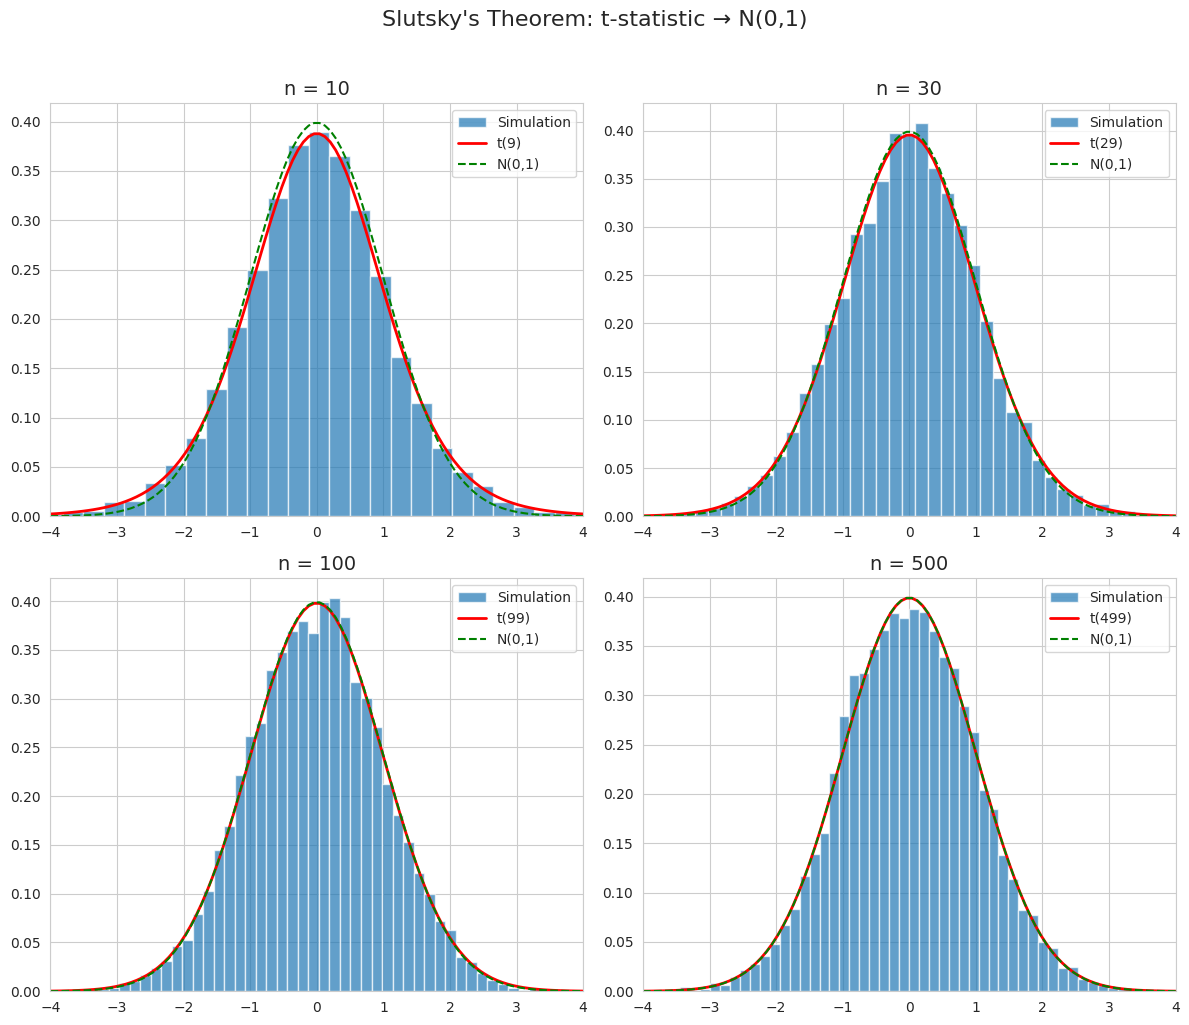

In [6]:
# スラツキーの定理の応用：t統計量
n_simulations = 10000
true_mu = 5
true_sigma = 2

sample_sizes = [10, 30, 100, 500]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, n in enumerate(sample_sizes):
    row, col = idx // 2, idx % 2
    
    samples = np.random.normal(true_mu, true_sigma, (n_simulations, n))
    sample_means = np.mean(samples, axis=1)
    sample_stds = np.std(samples, axis=1, ddof=1)
    
    # t統計量（未知の分散）
    t_stat = (sample_means - true_mu) / (sample_stds / np.sqrt(n))
    
    axes[row, col].hist(t_stat, bins=50, density=True, alpha=0.7, label='Simulation')
    x = np.linspace(-4, 4, 100)
    axes[row, col].plot(x, stats.t.pdf(x, n-1), 'r-', linewidth=2, label=f't({n-1})')
    axes[row, col].plot(x, stats.norm.pdf(x), 'g--', linewidth=1.5, label='N(0,1)')
    
    axes[row, col].set_title(f'n = {n}', fontsize=14)
    axes[row, col].legend()
    axes[row, col].set_xlim(-4, 4)

plt.suptitle("Slutsky's Theorem: t-statistic → N(0,1)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 7.5 連続写像定理

### 定理
$X_n \xrightarrow{d} X$ で $g$ が連続なら:
$$g(X_n) \xrightarrow{d} g(X)$$

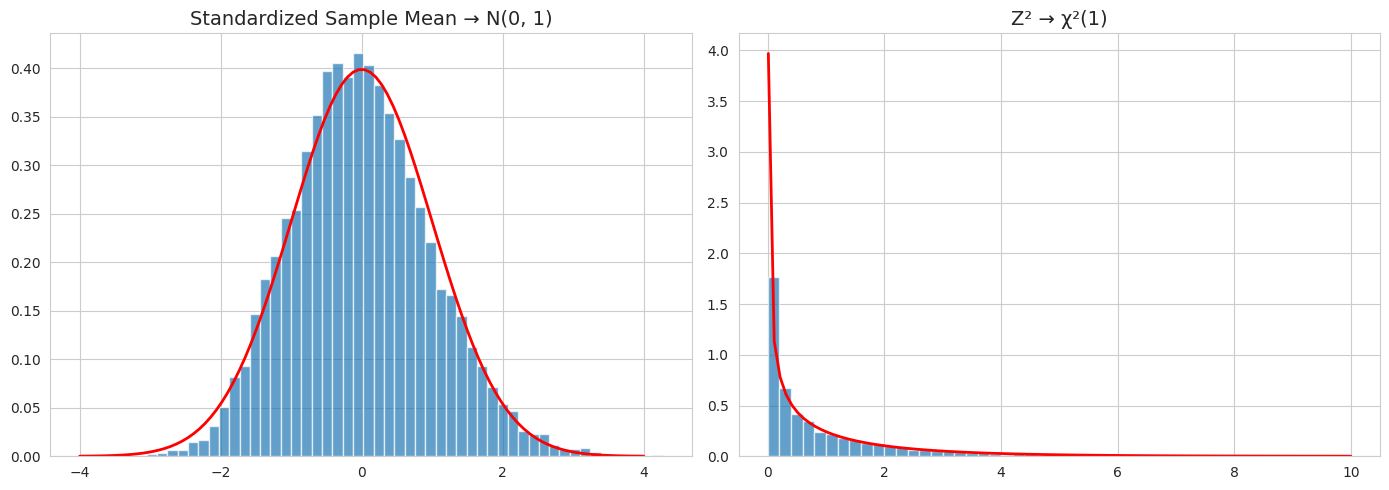

In [7]:
# 連続写像定理の例
n_simulations = 10000
n = 50

# 標準化された標本平均 → N(0, 1)
samples = np.random.exponential(1, (n_simulations, n))
sample_means = np.mean(samples, axis=1)
standardized = np.sqrt(n) * (sample_means - 1) / 1

# g(x) = x² を適用
squared = standardized**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 標準化された標本平均
axes[0].hist(standardized, bins=50, density=True, alpha=0.7)
x = np.linspace(-4, 4, 100)
axes[0].plot(x, stats.norm.pdf(x), 'r-', linewidth=2)
axes[0].set_title('Standardized Sample Mean → N(0, 1)', fontsize=14)

# 二乗 → χ²(1)
axes[1].hist(squared, bins=50, density=True, alpha=0.7, range=(0, 10))
x = np.linspace(0.01, 10, 100)
axes[1].plot(x, stats.chi2.pdf(x, 1), 'r-', linewidth=2)
axes[1].set_title('Z² → χ²(1)', fontsize=14)

plt.tight_layout()
plt.show()

## 7.6 練習問題

### 問題1
サイコロを600回投げたとき、1の目が出る回数が90回以上110回以下である確率を正規近似で求めよ。

### 問題2
$X_1, ..., X_{100} \sim$ iid $Exp(2)$ のとき、$P(\bar{X} > 0.6)$ を正規近似で求めよ。

### 問題3
母集団の分散 $\sigma^2$ を推定する際、$\hat{\sigma} = \sqrt{S^2}$ を使う。デルタ法を用いて $\hat{\sigma}$ の漸近分散を求めよ。

In [8]:
# 問題1の解答
n, p = 600, 1/6
mu = n * p  # = 100
sigma = np.sqrt(n * p * (1 - p))  # ≈ 9.13

# 連続性補正を適用
prob = stats.norm.cdf(110.5, mu, sigma) - stats.norm.cdf(89.5, mu, sigma)
print(f"問題1: P(90 ≤ X ≤ 110) ≈ {prob:.4f}")

# 正確な二項分布との比較
exact_prob = stats.binom.cdf(110, n, p) - stats.binom.cdf(89, n, p)
print(f"正確値: {exact_prob:.4f}")

問題1: P(90 ≤ X ≤ 110) ≈ 0.7499
正確値: 0.7501


In [9]:
# 問題2の解答
n = 100
lam = 2
mu = 1 / lam  # = 0.5
sigma = 1 / lam  # = 0.5

# X̄ の分布: N(0.5, 0.25/100)
prob = 1 - stats.norm.cdf(0.6, mu, sigma / np.sqrt(n))
print(f"問題2: P(X̄ > 0.6) ≈ {prob:.4f}")

問題2: P(X̄ > 0.6) ≈ 0.0228


In [10]:
# 問題3の解答
print("問題3: σ̂ = √S² の漸近分散")
print("="*50)
print("\ng(σ²) = √σ² = σ")
print("g'(σ²) = 1/(2σ)")
print("\nS² の漸近分散は 2σ⁴/n（正規母集団）")
print("\nデルタ法より:")
print("Var(σ̂) ≈ [g'(σ²)]² × Var(S²)")
print("       = [1/(2σ)]² × (2σ⁴/n)")
print("       = σ²/(2n)")

問題3: σ̂ = √S² の漸近分散

g(σ²) = √σ² = σ
g'(σ²) = 1/(2σ)

S² の漸近分散は 2σ⁴/n（正規母集団）

デルタ法より:
Var(σ̂) ≈ [g'(σ²)]² × Var(S²)
       = [1/(2σ)]² × (2σ⁴/n)
       = σ²/(2n)


## ⚠️ よくある間違いと解決策

### ❌ サンプルサイズの誤解
**正しい理解:** 「n≥30なら中心極限定理が使える」は目安に過ぎない
**解決策:** 元の分布の形状によってはもっと大きなnが必要

### ❌ 大数の法則とCLTの混同
**正しい理解:** 大数の法則は収束、CLTは分布の形を示す
**解決策:** LLN:X̄→μ、CLT:√n(X̄-μ)→N(0,σ²)

---

## 📝 理解度チェッククイズ

### 問題 1
中心極限定理の3つの条件を述べよ

### 問題 2
大数の法則と中心極限定理の違いは何か？

---

## 📚 まとめ

お疲れ様でした！この章で学んだ内容は、今後の章で繰り返し使います。

---